# Lab 2: Perceptron and Single Neuron with Different Activation Functions

## Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## Part A: Implement Perceptron with Step Activation

### Dataset Generation

In [2]:
half_rows, cols = 250, 2
X0 = np.random.randn(half_rows, cols) + np.array([-1, -1])
X1 = np.random.randn(half_rows, cols) + np.array([1, 1])

y0 = np.zeros(half_rows)
y1 = np.ones(half_rows)

X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

### Step activation function and loss function

In [3]:
def step_activation(z):
    return np.where(z >= 0, 1, 0)

def binary_cross_entropy(y, y_hat):
    eps = 1e-9 
    return -(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

### Training the Perceptron

In [4]:
w_step = np.zeros(2)
b_step = 0.0
lr = 0.05
epochs = 300
step_loss_history = []

for epoch in range(epochs):
    z = np.dot(X, w_step) + b_step
    y_hat = step_activation(z)

    loss = np.mean(binary_cross_entropy(y, y_hat))
    step_loss_history.append(loss)

    # Gradients
    dw = np.dot(X.T, (y_hat - y)) / len(y)
    db = np.mean(y_hat - y)

    # Update
    w_step -= lr * dw
    b_step -= lr * db

### Trained Parameters

In [5]:
print("Final Weights:", w_step)
print("Final Bias:", b_step)

Final Weights: [0.0153198  0.01067309]
Final Bias: 0.015599999999999992


### Decision Boundary

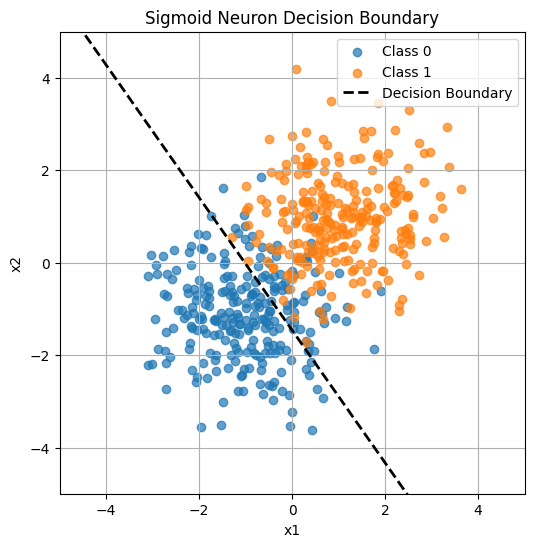

In [6]:
plt.figure(figsize=(6, 6))

plt.scatter(X0[:, 0], X0[:, 1], alpha=0.7, label="Class 0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.7, label="Class 1")

x_vals = np.linspace(-5, 5, 200)

if w_step[1] != 0:
    y_vals = -(w_step[0] * x_vals + b_step) / w_step[1]
    plt.plot(x_vals, y_vals, 'k--', linewidth=2, label="Decision Boundary")

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Sigmoid Neuron Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

## Part B: Single Neuron with Sigmoid Activation

### Activation and Loss Functions (Sigmoid & BCE Loss)

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y, y_hat):
    eps = 1e-9 
    return -(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

### Initialize Parameters

In [8]:
w_sig = np.random.randn(2)
b_sig = 0.0
lr = 0.05
epochs = 300

sig_loss_history = []

### Training Using Gradient Descent

In [9]:
for epoch in range(epochs):
    z = np.dot(X, w_sig) + b_sig
    y_hat = sigmoid(z)

    loss = np.mean(binary_cross_entropy(y, y_hat))
    sig_loss_history.append(loss)

    # Gradients
    dw = np.dot(X.T, (y_hat - y)) / len(y)
    db = np.mean(y_hat - y)

    # Update
    w_sig -= lr * dw
    b_sig -= lr * db

### Loss vs Epochs

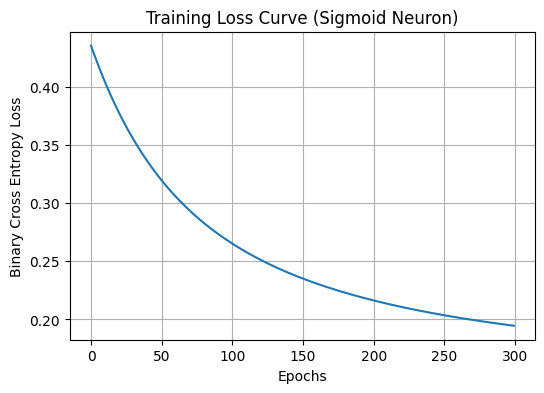

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(sig_loss_history)
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss Curve (Sigmoid Neuron)")
plt.grid(True)
plt.show()

### Decision Boundary (Sigmoid Neuron)

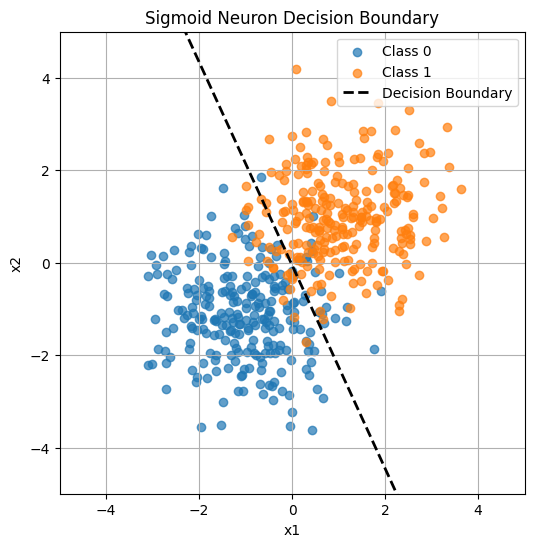

In [11]:
plt.figure(figsize=(6, 6))

plt.scatter(X0[:, 0], X0[:, 1], alpha=0.7, label="Class 0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.7, label="Class 1")

x_vals = np.linspace(-5, 5, 200)

if w_sig[1] != 0:
    y_vals = -(w_sig[0] * x_vals + b_sig) / w_sig[1]
    plt.plot(x_vals, y_vals, 'k--', linewidth=2, label="Decision Boundary")

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Sigmoid Neuron Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

### Accuracy Comparison (Step vs Sigmoid)

In [12]:
y_pred_step = (step_activation(np.dot(X, w_step) + b_step) >= 0.5).astype(int)
step_accuracy = np.mean(y_pred_step == y)

print("Step Neuron Accuracy:", step_accuracy)

Step Neuron Accuracy: 0.872


In [13]:
y_pred_sigmoid = (sigmoid(np.dot(X, w_sig) + b_sig) >= 0.5).astype(int)
sigmoid_accuracy = np.mean(y_pred_sigmoid == y)

print("Sigmoid Neuron Accuracy:", sigmoid_accuracy)

Sigmoid Neuron Accuracy: 0.914


## Part C: Comparison on Linear vs XOR Dataset

### XOR Dataset

In [14]:
# XOR dataset
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

### XOR Scatter

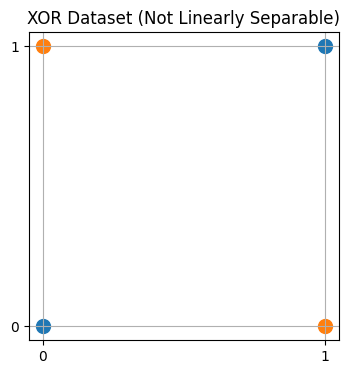

In [15]:
plt.figure(figsize=(4, 4))
    
plt.scatter(X_xor[y_xor == 0][:, 0], X_xor[y_xor == 0][:, 1], s=100, label="Class 0")
plt.scatter(X_xor[y_xor == 1][:, 0], X_xor[y_xor == 1][:, 1], s=100, label="Class 1")

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True)
plt.title("XOR Dataset (Not Linearly Separable)")
plt.show()

### Step Perceptron on XOR Dataset

In [16]:
w_step = np.random.randn(2)
b_step = 0.0
lr = 0.05
epochs = 300

for epoch in range(epochs):
    z = np.dot(X, w_step) + b_step
    y_hat = sigmoid(z)

    dw = np.dot(X.T, (y_hat - y)) / len(y)
    db = np.mean(y_hat - y)

    w_step -= lr * dw
    b_step -= lr * db

### Accuracy: Step Perceptron (XOR)

In [17]:
y_step_pred = step_activation(np.dot(X_xor, w_step) + b_step)
step_xor_acc = np.mean(y_step_pred == y_xor)

print("Step Perceptron XOR Accuracy:", step_xor_acc)

Step Perceptron XOR Accuracy: 0.5


### Sigmoid Neuron on XOR Dataset

In [18]:
w_sig = np.random.randn(2)
b_sig = 0.0
lr = 0.05
epochs = 300

for epoch in range(epochs):
    z = np.dot(X, w_sig) + b_sig
    y_hat = sigmoid(z)

    dw = np.dot(X.T, (y_hat - y)) / len(y)
    db = np.mean(y_hat - y)

    w_sig -= lr * dw
    b_sig -= lr * db

### Accuracy: Sigmoid Neuron (XOR)

In [19]:
y_sig_pred = (sigmoid(np.dot(X_xor, w_sig) + b_sig) >= 0.5).astype(int)
sigmoid_xor_acc = np.mean(y_sig_pred == y_xor)

print("Sigmoid Neuron XOR Accuracy:", sigmoid_xor_acc)

Sigmoid Neuron XOR Accuracy: 0.5


### Performance Comparison

In [20]:
print(f'''Linear Dataset:
    step activation acc: {step_accuracy}
    sigmoid activation acc: {sigmoid_accuracy}
XOR Dataset:
    step activation acc: {step_xor_acc}
    sigmoid activation acc: {sigmoid_xor_acc}''')

Linear Dataset:
    step activation acc: 0.872
    sigmoid activation acc: 0.914
XOR Dataset:
    step activation acc: 0.5
    sigmoid activation acc: 0.5


### Why XOR Fails

- XOR is not linearly separable
- A single neuron learns only linear decision boundaries
- No straight line can separate XOR classes
- Multi-layer networks are required